# DAY 2 추가 모델 및 앙상블 비교
울산캠퍼스 2반 · U040 김가연 · U067 이준희

기존 Elastic Net보다 나은 후보가 있는지 확인하는 **추가 실험**이다. 원래 Day2 제출 노트북과 보고서는 보존한다.
- Regression / Batch 1 학습 및 내부 검증 / Batch 2 테스트만 평가한다.
- 기존 개발용 28셀, Hold-out 8셀, 충전 정책 그룹별 4-fold 분할을 유지한다.
- Batch 2와 Hold-out 결과는 이전에 확인한 이력이 있다. 새 미관측 평가가 아닌 탐색적 재분석이다.
- 새 후보는 개발용 CV 평균 MAPE로만 선택하고, 선택 설정 저장 후 평가한다.
- 후보를 많이 비교한 최저 CV에는 선택 낙관성이 있을 수 있다. 최종 도입에는 새 독립 데이터가 필요하다.


## 1 실행 환경과 평가 지표
필요한 라이브러리, seed=42와 MAPE 목표 9.1%를 설정한다.

In [1]:
from pathlib import Path
import hashlib, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, joblib
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

SEED = 42
HOLDOUT_RATIO = 0.25   # 정책 그룹의 약 25%; 실제 셀 수 비율은 조금 다를 수 있음
CV_FOLDS = 4

TARGET_MAPE = 9.1     # 과제에서 제공한 비교 기준(%)
print('scikit-learn:', sklearn.__version__)
print('seed:', SEED, '| evaluation: Batch1 / Batch2 only')

scikit-learn: 1.9.1
seed: 42 | evaluation: Batch1 / Batch2 only


## 2 초기 피처와 데이터 읽기
초기 100사이클 피처를 읽고 결측 라벨을 제외한다. 1개/5개/8개 조합은 원래 정의를 유지한다. 추가 실험 결과는 output/day2_ensemble에 별도로 저장한다.

In [2]:
# 노트북 실행 디렉터리 또는 상위 디렉터리에서 프로젝트를 찾는다.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'processed/day1_final_features.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('프로젝트 폴더에서 노트북을 열고 processed/day1_final_features.csv를 확인하세요.')
DATA_PATH = ROOT / 'processed/day1_final_features.csv'
OUT = ROOT / 'output/day2_ensemble'
OUT.mkdir(parents=True, exist_ok=True)
DATA_HASH = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
raw = pd.read_csv(DATA_PATH)
# 기존 EDA 라벨 처리와 ΔQ를 유지하고 방전/추가 신호 피처를 명시적으로 계산한다.
raw = raw.loc[raw.batch.isin(['Batch1','Batch2'])].copy()
raw['delta_q_log_abs_min'] = np.log10(np.abs(raw['delta_q_min']).clip(lower=1e-12))
summary_hashes={}
extra=[]
for batch,file in [('Batch1','batch1_summary.csv.gz'),('Batch2','batch2_summary.csv.gz')]:
    path=ROOT/'processed'/file
    summary_hashes[file]=hashlib.sha256(path.read_bytes()).hexdigest()
    summary=pd.read_csv(path)
    for cid,g in summary.groupby('cell_id'):
        # 초기 100사이클만 사용한다. 제공 Summary의 기존 QD 불연속 기록 처리를 유지한다.
        early=g.loc[g.cycle.between(2,100)].sort_values('cycle')
        q2=early.loc[early.cycle.eq(2),'QD']
        assert len(q2)==1, f'{batch} cell {cid}: cycle 2 missing'
        extra.append({'batch':batch,'cell_id':cid,'qd_cycle2':float(q2.iloc[0]),
                      'qd_max_minus_cycle2':float(early.QD.max()-q2.iloc[0]),
                      'qd_slope_cycle2_100':float(np.polyfit(early.cycle,early.QD,1)[0])})
raw=raw.merge(pd.DataFrame(extra),on=['batch','cell_id'],validate='one_to_one')
FEATURE_SETS={
    'A_variance':['delta_q_log_variance'],
    'B_discharge_adapted':['delta_q_log_variance','delta_q_log_abs_min','qd_cycle2','qd_max_minus_cycle2','qd_slope_cycle2_100'],
    'C_signals_adapted':['delta_q_log_variance','delta_q_log_abs_min','qd_cycle2','qd_max_minus_cycle2','qd_slope_cycle2_100','tavg_mean_100','ir_change_100','chargetime_mean_100'],
    'D_delta_current':['delta_q_log_variance','charge_I_qw_100'],
    'E_delta_chargetime':['delta_q_log_variance','chargetime_mean_100'],
}
FEATURES = list(dict.fromkeys(x for xs in FEATURE_SETS.values() for x in xs))
assert not raw.duplicated(['batch', 'cell_id']).any(), '셀 ID 중복 확인 필요'
assert {'batch','cell_id','cycle_life','charging_policy',*FEATURES}.issubset(raw.columns)
print('입력:', DATA_PATH.relative_to(ROOT))
print('결과:', OUT.relative_to(ROOT))
display(raw.groupby('batch').agg(total_cells=('cell_id','size'), labeled_cells=('cycle_life','count')))
if 'reason' in raw:
    display(raw.groupby(['batch','reason'], dropna=False).size().rename('cells').reset_index())
valid = raw.loc[np.isfinite(raw['cycle_life']) & (raw['cycle_life'] > 0)].copy()
assert valid.groupby('batch').size().to_dict() == {'Batch1':36,'Batch2':39}, '최종 라벨 처리 기준과 다릅니다.'
b1 = valid.loc[valid.batch == 'Batch1'].reset_index(drop=True)
b2 = valid.loc[valid.batch == 'Batch2'].reset_index(drop=True)

assert b1.charging_policy.notna().all(), '정책 그룹 누락 확인 필요'
display(valid.groupby('batch')[FEATURES].agg(lambda s: s.isna().sum()).rename_axis('missing feature counts'))
raw.to_csv(OUT/'model_input_features.csv',index=False)
(OUT/'feature_sets.json').write_text(json.dumps(FEATURE_SETS,ensure_ascii=False,indent=2))
print('CV 후보 피처 그룹:', {k:len(v) for k,v in FEATURE_SETS.items()})


입력: processed/day1_final_features.csv
결과: output/day2_ensemble
CV 후보 피처 그룹: {'A_variance': 1, 'B_discharge_adapted': 5, 'C_signals_adapted': 8, 'D_delta_current': 2, 'E_delta_chargetime': 2}


,total_cells,labeled_cells
batch,,
Batch1,46,36
Batch2,47,39


,batch,reason,cells
0,Batch1,provided_label,36
1,Batch1,unfinished_or_continuation_unavailable,10
2,Batch2,missing_target,8
3,Batch2,provided_label,39


,delta_q_log_variance,delta_q_log_abs_min,qd_cycle2,qd_max_minus_cycle2,qd_slope_cycle2_100,tavg_mean_100,ir_change_100,chargetime_mean_100,charge_I_qw_100
missing feature counts,,,,,,,,,
Batch1,0,0,0,0,0,0,0,0,0
Batch2,0,0,0,0,0,0,0,0,0


## 3 기존 Hold-out 분할 재사용
개발용 28셀과 Hold-out 8셀을 유지한다. 셀과 충전 정책이 두 집단에 중복되지 않는지 확인한다.

In [3]:
SPLIT_PATH = OUT / 'batch1_split.csv'
SPLIT_META = OUT / 'batch1_split_metadata.json'
if SPLIT_PATH.exists():
    meta = json.loads(SPLIT_META.read_text())
    assert meta['data_sha256'] == DATA_HASH, '데이터 변경: 기존 분할과 평가 이력을 먼저 검토하세요.'
    assert meta['seed'] == SEED and meta['holdout_ratio'] == HOLDOUT_RATIO, '기존 분할과 설정이 다릅니다.'
    saved = pd.read_csv(SPLIT_PATH)
    b1 = b1.merge(saved[['cell_id','split']], on='cell_id', validate='one_to_one')
    assert len(b1) == 36 and b1['split'].isin(['development','holdout']).all()
else:
    splitter = GroupShuffleSplit(n_splits=1, test_size=HOLDOUT_RATIO, random_state=SEED)
    dev_idx, hold_idx = next(splitter.split(b1, groups=b1.charging_policy))
    b1['split'] = 'development'
    b1.loc[hold_idx, 'split'] = 'holdout'
    b1[['batch','cell_id','charging_policy','split']].to_csv(SPLIT_PATH, index=False)
    SPLIT_META.write_text(json.dumps({'data_sha256':DATA_HASH,'seed':SEED,'holdout_ratio':HOLDOUT_RATIO}, indent=2))
dev = b1.loc[b1.split == 'development'].reset_index(drop=True)
hold = b1.loc[b1.split == 'holdout'].reset_index(drop=True)
assert set(dev.charging_policy).isdisjoint(set(hold.charging_policy))
display(b1.groupby('split').agg(cells=('cell_id','size'), policies=('charging_policy','nunique')))
display(b1[['cell_id','charging_policy','split']].sort_values(['split','charging_policy']))
print('수명값으로 분할을 다시 고르지 않습니다. 테스트는 아직 평가하지 않습니다.')

수명값으로 분할을 다시 고르지 않습니다. 테스트는 아직 평가하지 않습니다.


,cells,policies
split,,
development,28,15
holdout,8,5


,cell_id,charging_policy,split
3,9,5.4C(40%)-3.6C,development
4,11,5.4C(50%)-3C,development
7,16,5.4C(60%)-3.6C,development
8,17,5.4C(60%)-3.6C,development
5,14,5.4C(60%)-3C,development
6,15,5.4C(60%)-3C,development
9,18,5.4C(70%)-3C,development
10,19,5.4C(70%)-3C,development
11,20,5.4C(80%)-5.4C,development
12,21,5.4C(80%)-5.4C,development


## 4 그룹 교차검증 fold 재사용
개발용 셀을 충전 정책 그룹 단위로 4개 fold에 나눈다. 각 검증 fold의 정책은 해당 학습 fold에 포함되지 않는다.

In [4]:
n_splits = min(CV_FOLDS, dev.charging_policy.nunique())
assert n_splits >= 2
cv = GroupKFold(n_splits=n_splits)
folds = list(cv.split(dev, groups=dev.charging_policy))
fold_info = []
for k,(tr,va) in enumerate(folds,1):
    assert set(dev.iloc[tr].charging_policy).isdisjoint(set(dev.iloc[va].charging_policy))
    assert len(va) >= 2
    fold_info.append({'fold':k,'train_cells':len(tr),'valid_cells':len(va),
                      'train_policies':dev.iloc[tr].charging_policy.nunique(),
                      'valid_policies':dev.iloc[va].charging_policy.nunique()})
display(pd.DataFrame(fold_info))

,fold,train_cells,valid_cells,train_policies,valid_policies
0,1,20,8,11,4
1,2,21,7,11,4
2,3,21,7,11,4
3,4,22,6,12,3


## 5 모델과 앙상블 정의
SVR·Kernel Ridge·Bayesian Ridge·Extra Trees와 규제 선형·트리 모델을 비교한다. Bagging은 충전 정책 그룹을 복원 추출하여 여러 선형모델을 학습하고 평균한다. Voting은 미리 정한 구성원의 예측을 평균한다. 기하평균은 로그 예측을 평균한 뒤 원 수명으로 복원한다. Stacking은 학습 fold 내부의 그룹 OOF 예측으로 상위 Ridge 모델을 학습한다. OOF란 해당 셀을 학습하지 않은 모델의 예측이며, 정책도 분리한다. 검증 데이터로 상위 모델을 학습하지 않는다.

In [5]:
# 모델과 앙상블을 정의한다. 모든 후보는 Test 평가 전에 고정한다.
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import BayesianRidge, HuberRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.base import BaseEstimator, RegressorMixin
import cloudpickle, warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

def metrics(y,p):
    assert np.isfinite(p).all() and (np.asarray(p)>0).all()
    return {'MAPE_pct':mean_absolute_percentage_error(y,p)*100,
            'MAE_cycles':mean_absolute_error(y,p),
            'RMSE_cycles':float(np.sqrt(mean_squared_error(y,p)))}

specs=[]
def add(model,fs='B_discharge_adapted',target='log10',**params):
    sid=f'{model}_{fs}_{target}_{len(specs):03d}'
    specs.append({'id':sid,'model':model,'feature_set':fs,'target':target,'params':params})
for fs in ['A_variance','B_discharge_adapted','C_signals_adapted']:
    for a in [.0001,.0003,.001,.003,.01]:
        for ratio in [.1,.5,.9]:add('ElasticNet',fs,alpha=a,l1_ratio=ratio)
    for a in [.01,.1,1.,10.,100.]:add('Ridge',fs,alpha=a)
    add('BayesianRidge',fs)
    for c in [.03,.1,.3,1.]:
        for ep in [.005,.02]:add('SVR',fs,C=c,epsilon=ep,kernel='rbf',gamma='scale')
    for a in [.01,.1,1.]:
        for gamma in [.01,.1,1.]:add('KernelRidge',fs,alpha=a,kernel='rbf',gamma=gamma)
    for depth in [2,4,None]:
        for leaf in [2,4]:add('ExtraTrees',fs,max_depth=depth,min_samples_leaf=leaf)
    for depth in [2,4]:add('RandomForest',fs,max_depth=depth,min_samples_leaf=3)
    for depth in [1,2]:add('GradientBoosting',fs,max_depth=depth)
    # 원 Target 후보도 포함한다. 단위가 다른 SVR epsilon은 사이클 단위로 지정한다.
    for a in [.1,1.,10.]:add('Ridge',fs,'raw',alpha=a)
    for c in [100.,500.]:add('SVR',fs,'raw',C=c,epsilon=10.,kernel='rbf',gamma='scale')

# 앙상블 구성원의 설정은 미리 고정한다. 전역 CV 승자를 구성원으로 다시 선택하지 않는다.
BASES={
 'en':{'model':'ElasticNet','target':'log10','params':{'alpha':.001,'l1_ratio':.5}},
 'ridge':{'model':'Ridge','target':'log10','params':{'alpha':.1}},
 'svr':{'model':'SVR','target':'log10','params':{'C':.1,'epsilon':.005,'kernel':'rbf','gamma':'scale'}},
 'krr':{'model':'KernelRidge','target':'log10','params':{'alpha':.1,'kernel':'rbf','gamma':.1}},
 'extra':{'model':'ExtraTrees','target':'log10','params':{'max_depth':4,'min_samples_leaf':2}},
}
for fs in ['B_discharge_adapted','C_signals_adapted']:
    for names in [['en','ridge'],['en','svr'],['en','krr'],['en','extra'],['en','svr','krr'],['en','svr','extra']]:
        for mode in ['arithmetic','geometric']:
            add('Voting',fs,names=names,mode=mode,weights=[1.]*len(names))
    for weight in [.25,.75]:
        add('Voting',fs,names=['en','svr'],mode='arithmetic',weights=[weight,1-weight])
    for alpha in [1.,10.]:
        add('Stacking',fs,names=['en','svr','extra'],alpha=alpha)

# 기존 최종 모델을 명시적으로 유지해 동일 fold에서 비교한다.
BASELINE={'id':'Existing_ElasticNet','model':'ElasticNet','feature_set':'B_discharge_adapted','target':'log10','params':{'alpha':.001,'l1_ratio':.5}}
specs.append(BASELINE)

def simple(spec):
    name,p=spec['model'],spec['params']
    if name=='ElasticNet':m=ElasticNet(**p,max_iter=50000,random_state=SEED)
    elif name=='Ridge':m=Ridge(**p)
    elif name=='BayesianRidge':m=BayesianRidge()
    elif name=='SVR':m=SVR(**p)
    elif name=='KernelRidge':m=KernelRidge(**p)
    elif name=='ExtraTrees':m=ExtraTreesRegressor(**p,n_estimators=100,random_state=SEED,n_jobs=1)
    elif name=='RandomForest':m=RandomForestRegressor(**p,n_estimators=100,random_state=SEED,n_jobs=1)
    elif name=='GradientBoosting':m=GradientBoostingRegressor(**p,n_estimators=100,learning_rate=.03,min_samples_leaf=3,random_state=SEED)
    else:raise ValueError(name)
    pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('scale',StandardScaler()),('model',m)])
    return TransformedTargetRegressor(regressor=pipe,func=np.log10,inverse_func=lambda z:10.**z) if spec['target']=='log10' else pipe

class FixedVoting(RegressorMixin, BaseEstimator):
    def __init__(self,names,mode='arithmetic',weights=None):self.names=names;self.mode=mode;self.weights=weights
    def fit(self,X,y,groups=None):
        self.models_=[simple(BASES[name]).fit(X,y) for name in self.names];return self
    def predict(self,X):
        a=np.column_stack([m.predict(X) for m in self.models_])
        return np.average(a,axis=1,weights=self.weights) if self.mode=='arithmetic' else 10.**np.average(np.log10(a),axis=1,weights=self.weights)

class GroupStacking(RegressorMixin, BaseEstimator):
    def __init__(self,names,alpha=1.):self.names=names;self.alpha=alpha
    def fit(self,X,y,groups=None):
        # 각 바깥 학습 fold 안에서만 OOF 예측을 만든다. 검증·Hold-out은 제외한다.
        assert groups is not None
        X=X.reset_index(drop=True);y=np.asarray(y);groups=np.asarray(groups)
        inner=GroupKFold(n_splits=min(3,len(np.unique(groups))))
        oof=np.full((len(y),len(self.names)),np.nan)
        for tr,va in inner.split(X,groups=groups):
            assert set(groups[tr]).isdisjoint(set(groups[va]))
            for j,name in enumerate(self.names):
                m=simple(BASES[name]);m.fit(X.iloc[tr],y[tr]);oof[va,j]=np.log10(m.predict(X.iloc[va]))
        assert np.isfinite(oof).all()
        self.meta_=Pipeline([('scale',StandardScaler()),('ridge',Ridge(alpha=self.alpha))]).fit(oof,np.log10(y))
        self.models_=[simple(BASES[name]).fit(X,y) for name in self.names]
        return self
    def predict(self,X):
        a=np.column_stack([np.log10(m.predict(X)) for m in self.models_]);return 10.**self.meta_.predict(a)

def build(spec):
    if spec['model']=='Voting':return FixedVoting(**spec['params'])
    if spec['model']=='Stacking':return GroupStacking(**spec['params'])
    return simple(spec)
def fit_est(est,spec,frame):
    X=frame[FEATURE_SETS[spec['feature_set']]];y=frame.cycle_life
    if spec['model']=='Stacking':return est.fit(X,y,groups=frame.charging_policy)
    return est.fit(X,y)
spec_by_id={s['id']:s for s in specs}
assert len(spec_by_id)==len(specs)
print('고정 후보 수:',len(specs),'| outer CV:',len(folds),'| Stacking은 내부 그룹 CV로 OOF 생성')

class PolicyBagging(RegressorMixin, BaseEstimator):
    def __init__(self,name='en',fraction=1.,n_estimators=40):self.name=name;self.fraction=fraction;self.n_estimators=n_estimators
    def fit(self,X,y,groups=None):
        assert groups is not None
        X=X.reset_index(drop=True);y=np.asarray(y);groups=np.asarray(groups)
        keys=np.unique(groups);rng=np.random.default_rng(SEED);self.models_=[]
        for _ in range(self.n_estimators):
            # 정책 그룹을 복원 추출한다. 각 선택 그룹에 속한 셀을 함께 재표집한다.
            draw=rng.choice(keys,size=max(2,int(np.ceil(len(keys)*self.fraction))),replace=True)
            idx=np.concatenate([np.flatnonzero(groups==g) for g in draw])
            self.models_.append(simple(BASES[self.name]).fit(X.iloc[idx],y[idx]))
        return self
    def predict(self,X):return np.mean(np.column_stack([m.predict(X) for m in self.models_]),axis=1)

for fs in ['B_discharge_adapted','C_signals_adapted']:
    for name in ['en','ridge']:
        for fraction in [.75,1.]:add('Bagging',fs,name=name,fraction=fraction,n_estimators=40)
_old_build=build
_old_fit=fit_est
def build(spec):
    return PolicyBagging(**spec['params']) if spec['model']=='Bagging' else _old_build(spec)
def fit_est(est,spec,frame):
    if spec['model']=='Bagging':return est.fit(frame[FEATURE_SETS[spec['feature_set']]],frame.cycle_life,groups=frame.charging_policy)
    return _old_fit(est,spec,frame)
spec_by_id={s['id']:s for s in specs}
print('Bagging을 포함한 전체 고정 후보:',len(specs))


고정 후보 수: 192 | outer CV: 4 | Stacking은 내부 그룹 CV로 OOF 생성
Bagging을 포함한 전체 고정 후보: 200


## 6 동일 그룹 CV로 비교하고 후보 고정
각 후보를 같은 4개 fold에서 평가한다. 평균 MAPE 최소, 동률이면 작은 표준편차를 선택한다. 기존 모델과 최상위 앙상블의 점수도 비교한다. 이 단계에서는 Hold-out/Test 점수를 계산하지 않는다. Stacking의 내부 CV는 OOF 생성용이며 전체 후보 탐색의 nested CV 평가는 아니다.

In [6]:
# 개발용 28셀만으로 후보를 비교한다. Hold-out과 Batch2로 선택하지 않는다.
cv_rows=[];fold_rows=[];oof_rows=[];failed_rows=[];started=time.perf_counter()
for i,s in enumerate(specs,1):
    scores=[]
    for k,(tr,va) in enumerate(folds,1):
        try:
            m=fit_est(build(s),s,dev.iloc[tr])
            pred=m.predict(dev.iloc[va][FEATURE_SETS[s['feature_set']]])
            if not (np.isfinite(pred).all() and (pred>0).all()):
                raise ValueError('CV에서 비정상 또는 음수 수명 예측 발생')
        except (ValueError, FloatingPointError) as ex:
            failed_rows.append({'candidate_id':s['id'],'fold':k,'reason':str(ex)})
            break
        score=metrics(dev.iloc[va].cycle_life,pred);scores.append(score)
        fold_rows.append({'candidate_id':s['id'],'fold':k,**score})
        for cid,y,p in zip(dev.iloc[va].cell_id,dev.iloc[va].cycle_life,pred):oof_rows.append({'candidate_id':s['id'],'fold':k,'cell_id':cid,'actual':y,'predicted':p})
    if len(scores)!=len(folds):continue
    ss=pd.DataFrame(scores)
    cv_rows.append({'candidate_id':s['id'],'model':s['model'],'feature_set':s['feature_set'],'target':s['target'],'params':json.dumps(s['params']),'CV_MAPE_mean':ss.MAPE_pct.mean(),'CV_MAPE_std':ss.MAPE_pct.std(ddof=1),'CV_RMSE_mean':ss.RMSE_cycles.mean()})
    if i%20==0:print(i,'/',len(specs),'후보 완료')
cv_results=pd.DataFrame(cv_rows).sort_values(['CV_MAPE_mean','CV_MAPE_std']).reset_index(drop=True)
cv_results.to_csv(OUT/'cv_candidates.csv',index=False)
pd.DataFrame(failed_rows,columns=['candidate_id','fold','reason']).to_csv(OUT/'failed_candidates.csv',index=False)
pd.DataFrame(fold_rows).to_csv(OUT/'cv_fold_scores.csv',index=False)
pd.DataFrame(oof_rows).to_csv(OUT/'cv_oof_predictions.csv',index=False)
chosen=spec_by_id[cv_results.iloc[0].candidate_id]
best_ensemble=spec_by_id[cv_results.loc[cv_results.model.isin(['Voting','Stacking','Bagging'])].iloc[0].candidate_id]
freeze={'data_sha256':DATA_HASH,'seed':SEED,'selection_rule':'개발용 CV 평균 MAPE 최소; 동률은 표준편차 최소','winner':chosen,'best_ensemble':best_ensemble,'n_candidates':len(specs),'test_not_used_for_selection':True,'prior_test_history':'previous Day2 Batch2 results already inspected; this is exploratory reanalysis'}
(OUT/'selection_frozen.json').write_text(json.dumps(freeze,ensure_ascii=False,indent=2))
display(cv_results.head(15));display(cv_results.groupby('model',sort=False).head(1))
print('CV 비교 완료 후 후보를 고정했습니다. 소요',round(time.perf_counter()-started,1),'초')


20 / 200 후보 완료
40 / 200 후보 완료
60 / 200 후보 완료
80 / 200 후보 완료
100 / 200 후보 완료
120 / 200 후보 완료
140 / 200 후보 완료
160 / 200 후보 완료
180 / 200 후보 완료
200 / 200 후보 완료
CV 비교 완료 후 후보를 고정했습니다. 소요 8.1 초


,candidate_id,model,feature_set,target,params,CV_MAPE_mean,CV_MAPE_std,CV_RMSE_mean
0,ElasticNet_B_discharge_adapted_log10_060,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.001, ""l1_ratio"": 0.5}",4.775134,1.718035,51.256704
1,Existing_ElasticNet,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.001, ""l1_ratio"": 0.5}",4.775134,1.718035,51.256704
2,ElasticNet_B_discharge_adapted_log10_062,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.003, ""l1_ratio"": 0.1}",4.899610,1.644689,51.487157
3,BayesianRidge_B_discharge_adapted_log10_073,BayesianRidge,B_discharge_adapted,log10,{},4.927608,1.875079,52.815713
4,ElasticNet_B_discharge_adapted_log10_061,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.001, ""l1_ratio"": 0.9}",4.975081,1.448988,51.928919
5,Voting_B_discharge_adapted_log10_159,Voting,B_discharge_adapted,log10,"{""names"": [""en"", ""ridge""], ""mode"": ""arithmetic...",4.983846,1.527879,51.716235
6,Voting_B_discharge_adapted_log10_160,Voting,B_discharge_adapted,log10,"{""names"": [""en"", ""ridge""], ""mode"": ""geometric""...",4.986760,1.524173,51.723502
7,Ridge_B_discharge_adapted_log10_070,Ridge,B_discharge_adapted,log10,"{""alpha"": 1.0}",4.993773,1.938976,53.278693
8,ElasticNet_B_discharge_adapted_log10_063,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.003, ""l1_ratio"": 0.5}",5.063516,1.498392,53.193465
9,ElasticNet_B_discharge_adapted_log10_065,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.01, ""l1_ratio"": 0.1}",5.110245,1.610289,53.688839


,candidate_id,model,feature_set,target,params,CV_MAPE_mean,CV_MAPE_std,CV_RMSE_mean
0,ElasticNet_B_discharge_adapted_log10_060,ElasticNet,B_discharge_adapted,log10,"{""alpha"": 0.001, ""l1_ratio"": 0.5}",4.775134,1.718035,51.256704
3,BayesianRidge_B_discharge_adapted_log10_073,BayesianRidge,B_discharge_adapted,log10,{},4.927608,1.875079,52.815713
5,Voting_B_discharge_adapted_log10_159,Voting,B_discharge_adapted,log10,"{""names"": [""en"", ""ridge""], ""mode"": ""arithmetic...",4.983846,1.527879,51.716235
7,Ridge_B_discharge_adapted_log10_070,Ridge,B_discharge_adapted,log10,"{""alpha"": 1.0}",4.993773,1.938976,53.278693
13,Stacking_B_discharge_adapted_log10_173,Stacking,B_discharge_adapted,log10,"{""names"": [""en"", ""svr"", ""extra""], ""alpha"": 1.0}",5.391783,1.755964,53.570926
14,Bagging_B_discharge_adapted_log10_193,Bagging,B_discharge_adapted,log10,"{""name"": ""en"", ""fraction"": 1.0, ""n_estimators""...",5.417529,1.275315,54.418510
59,ExtraTrees_B_discharge_adapted_log10_093,ExtraTrees,B_discharge_adapted,log10,"{""max_depth"": 4, ""min_samples_leaf"": 2}",7.967971,3.567666,73.541665
66,KernelRidge_A_variance_log10_029,KernelRidge,A_variance,log10,"{""alpha"": 0.01, ""kernel"": ""rbf"", ""gamma"": 0.01}",8.489053,3.250233,77.051151
68,SVR_A_variance_raw_052,SVR,A_variance,raw,"{""C"": 500.0, ""epsilon"": 10.0, ""kernel"": ""rbf"",...",8.625602,2.770418,79.314647
116,GradientBoosting_A_variance_log10_046,GradientBoosting,A_variance,log10,"{""max_depth"": 1}",9.613289,4.125561,89.877033


## 7 고정 후보의 Hold-out 및 Batch 2 평가
기존 모델, CV 승자, 가장 좋은 앙상블만 평가한다. 테스트 성능을 본 뒤 모델을 교체하지 않는다. 파일 저장과 원 모델 결과 재현을 검증한다. MAPE 행은 %, Gap은 %p다.

,candidate_id,model,feature_set,CV_MAPE,CV_std,Valid_MAPE,Test_MAPE,Test_MAE,Test_RMSE
0,Existing_ElasticNet,ElasticNet,B_discharge_adapted,4.775,1.718,5.695,25.642,155.607,223.144
1,ElasticNet_B_discharge_adapted_log10_060,ElasticNet,B_discharge_adapted,4.775,1.718,5.695,25.642,155.607,223.144
2,Voting_B_discharge_adapted_log10_159,Voting,B_discharge_adapted,4.984,1.528,5.735,25.368,154.097,221.458


,구분,MAPE (%),비고
0,Train (Batch 1 CV),4.775,개발용 그룹 CV 평균
1,Valid (Batch 1 Hold-out),5.695,셀·충전 정책 그룹 Hold-out
2,Test (Batch 2),25.642,Batch1 전체 재학습 후 고정 후보 평가
3,Gap (Train-Valid),0.920,(+) : 과적합 의심; Valid - Train (%p)
4,Gap (Valid-Test),19.948,(+) : 배치간 일반화 저하 의심; Test - Valid (%p)
5,Gap (Target-Test),16.542,Target : 원논문9.1%; Test - Target (%p)


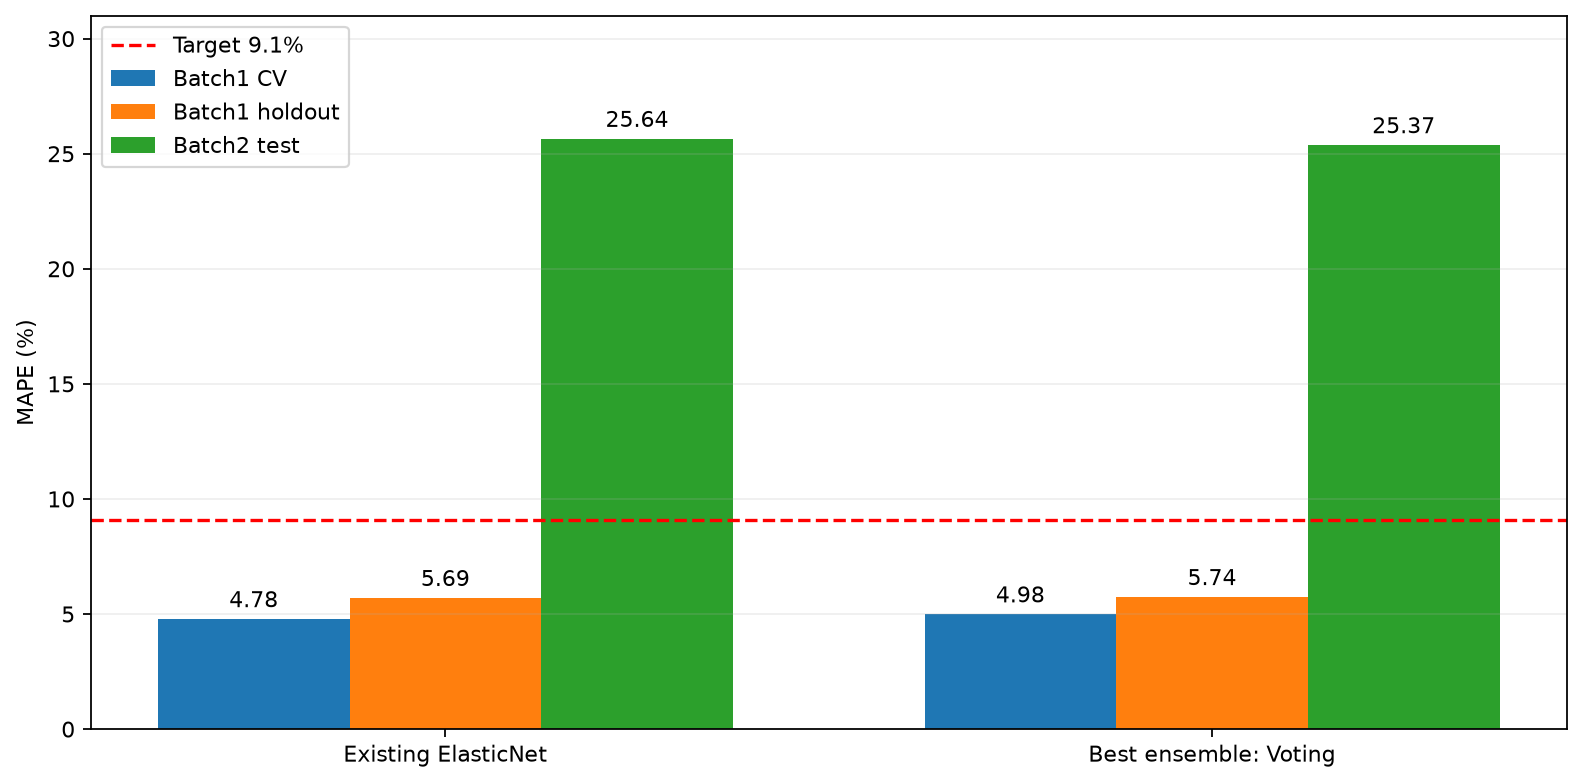

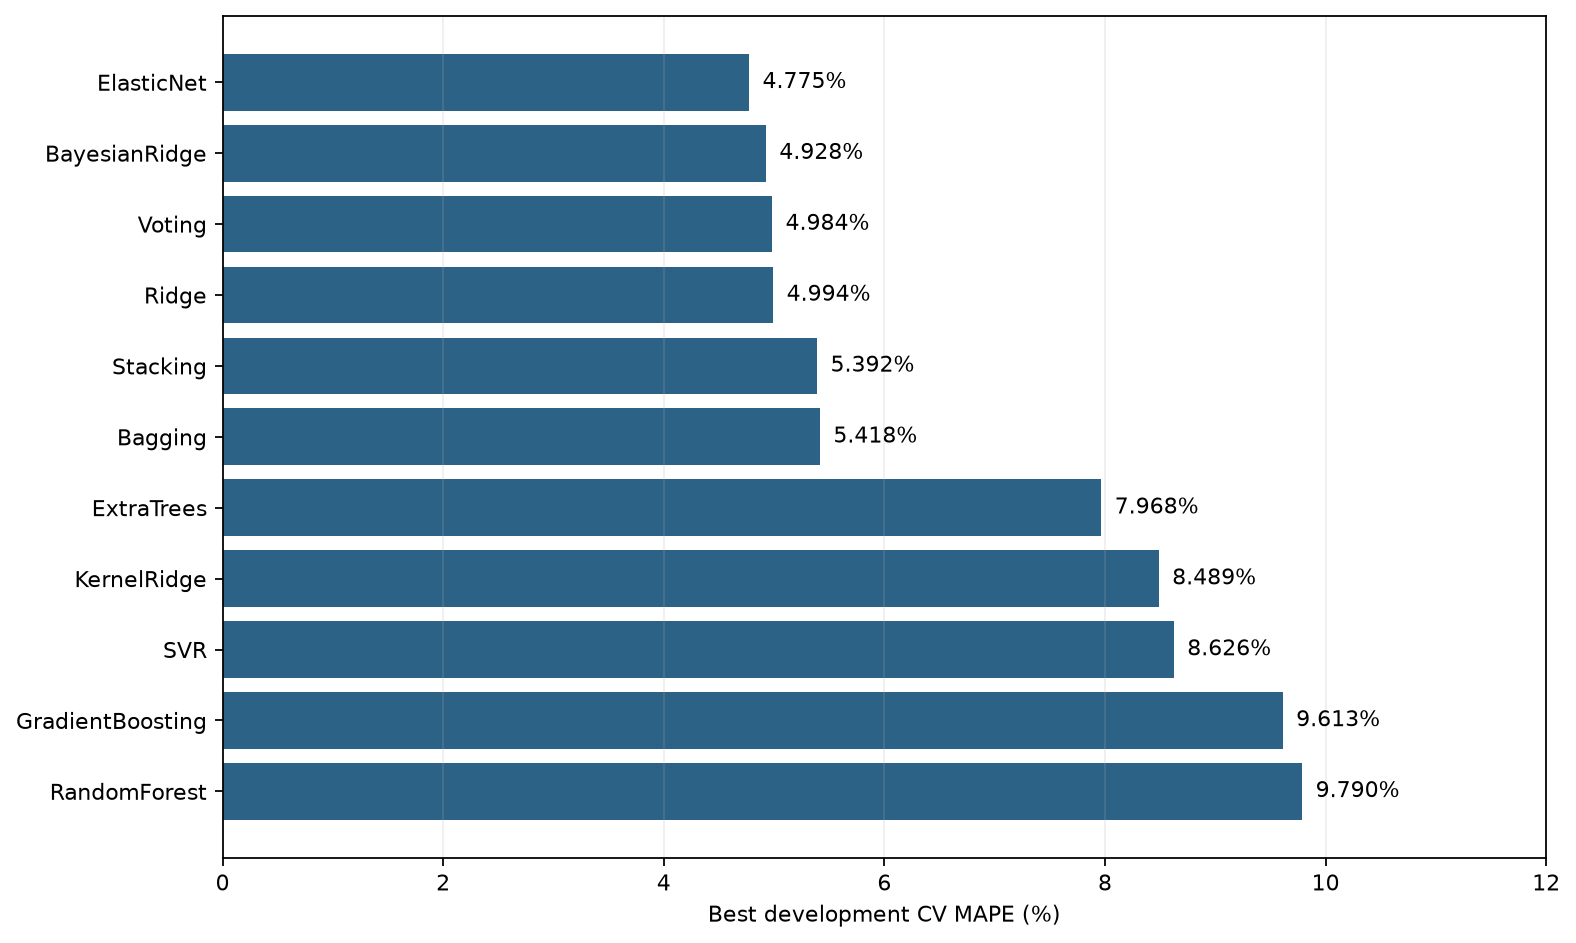

In [7]:
# CV로 고정한 새 승자·최상위 앙상블과 기존 모델만 평가한다.
ids=list(dict.fromkeys([BASELINE['id'],chosen['id'],best_ensemble['id']]))
rows=[];predrows=[];fitted={}
for sid in ids:
    s=spec_by_id[sid];cols=FEATURE_SETS[s['feature_set']]
    hm=fit_est(build(s),s,dev);hp=hm.predict(hold[cols]);vs=metrics(hold.cycle_life,hp)
    fm=fit_est(build(s),s,b1);tp=fm.predict(b2[cols]);ts=metrics(b2.cycle_life,tp);fitted[sid]=fm
    cr=cv_results.loc[cv_results.candidate_id.eq(sid)].iloc[0]
    rows.append({'candidate_id':sid,'model':s['model'],'feature_set':s['feature_set'],'CV_MAPE':cr.CV_MAPE_mean,'CV_std':cr.CV_MAPE_std,'Valid_MAPE':vs['MAPE_pct'],'Test_MAPE':ts['MAPE_pct'],'Test_MAE':ts['MAE_cycles'],'Test_RMSE':ts['RMSE_cycles']})
    for label,frame,pred in [('Holdout',hold,hp),('Batch2',b2,tp)]:
        for cid,y,p in zip(frame.cell_id,frame.cycle_life,pred):predrows.append({'candidate_id':sid,'dataset':label,'cell_id':cid,'actual':y,'predicted':p,'APE_pct':abs(p-y)/y*100})
    with (OUT/f'model_{sid}.pkl').open('wb') as f:cloudpickle.dump({'estimator':fm,'features':cols,'spec':s},f)
comparison=pd.DataFrame(rows);comparison.to_csv(OUT/'frozen_model_comparison.csv',index=False)
preds=pd.DataFrame(predrows);preds.to_csv(OUT/'predictions.csv',index=False)
display(comparison.round(3))
r=comparison.loc[comparison.candidate_id.eq(chosen['id'])].iloc[0]
report=pd.DataFrame([
 ['Train (Batch 1 CV)',r.CV_MAPE,'개발용 그룹 CV 평균'],
 ['Valid (Batch 1 Hold-out)',r.Valid_MAPE,'셀·충전 정책 그룹 Hold-out'],
 ['Test (Batch 2)',r.Test_MAPE,'Batch1 전체 재학습 후 고정 후보 평가'],
 ['Gap (Train-Valid)',r.Valid_MAPE-r.CV_MAPE,'(+) : 과적합 의심; Valid - Train (%p)'],
 ['Gap (Valid-Test)',r.Test_MAPE-r.Valid_MAPE,'(+) : 배치간 일반화 저하 의심; Test - Valid (%p)'],
 ['Gap (Target-Test)',r.Test_MAPE-9.1,'Target : 원논문9.1%; Test - Target (%p)'],
],columns=['구분','MAPE (%)','비고'])
report.to_csv(OUT/'performance_reporting.csv',index=False,encoding='utf-8-sig');display(report.round({'MAPE (%)':3}))
# 기존 Elastic Net의 결과가 이전 산출물과 같은지, 예측 저장/복원이 같은지 확인한다.
baseline=comparison.loc[comparison.candidate_id.eq(BASELINE['id'])].iloc[0]
np.testing.assert_allclose([baseline.CV_MAPE,baseline.Valid_MAPE,baseline.Test_MAPE],[4.775134352081155,5.694733210468472,25.642498635652842],rtol=1e-8)
for sid in ids:
    with (OUT/f'model_{sid}.pkl').open('rb') as f:restored=cloudpickle.load(f)
    np.testing.assert_allclose(restored['estimator'].predict(b2[restored['features']]),preds.loc[(preds.candidate_id==sid)&(preds.dataset=='Batch2'),'predicted'])
assert set(dev.charging_policy).isdisjoint(set(hold.charging_policy))
assert chosen['id']==cv_results.iloc[0].candidate_id
(OUT/'verification.json').write_text(json.dumps({'n_candidates':len(specs),'outer_fits':len(fold_rows),'stacking_inner_group_oof':True,'policy_overlap':0,'baseline_metrics_reproduced':True,'saved_predictions_match':True,'test_selected_only_after_cv_freeze':True,'test_history_disclosed':True},indent=2))
# 동일한 설정의 기존 모델과 CV 승자는 같은 행으로 그린다.
plotdata=comparison.drop_duplicates(subset=['model','feature_set','CV_MAPE','Valid_MAPE','Test_MAPE']).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(10,5));x=np.arange(len(plotdata));w=.25
for j,(c,label) in enumerate([('CV_MAPE','Batch1 CV'),('Valid_MAPE','Batch1 holdout'),('Test_MAPE','Batch2 test')]):
    bars=ax.bar(x+(j-1)*w,plotdata[c],w,label=label)
    ax.bar_label(bars,fmt='%.2f',padding=3)
ax.set_xticks(x,[('Existing ElasticNet' if sid==BASELINE['id'] else 'Best ensemble: '+m) for sid,m in zip(plotdata.candidate_id,plotdata.model)])
ax.axhline(9.1,color='red',ls='--',label='Target 9.1%');ax.set_ylabel('MAPE (%)');ax.set_ylim(0,31);ax.grid(axis='y',alpha=.2);ax.legend();fig.tight_layout();fig.savefig(OUT/'model_comparison.png',dpi=180);plt.show()
family=cv_results.groupby('model',sort=False).head(1).sort_values('CV_MAPE_mean',ascending=False)
fig,ax=plt.subplots(figsize=(10,6));ax.barh(family.model,family.CV_MAPE_mean,color='#2D6287');ax.set_xlabel('Best development CV MAPE (%)');ax.set_xlim(0,12);ax.grid(axis='x',alpha=.2)
for i,v in enumerate(family.CV_MAPE_mean):ax.text(v+.12,i,f'{v:.3f}%',va='center')
fig.tight_layout();fig.savefig(OUT/'cv_family_comparison.png',dpi=180);plt.show()


## 8 결과 해석과 판단
**결론: 이번 탐색에서는 기존 Elastic Net보다 CV가 낮은 모델을 찾지 못했다. 최종 모델은 유지한다.**

총 200개 설정을 시도했다. 199개는 4-fold 평가를 완료했고, 1개 원 Target Ridge 후보는 검증 fold에서 음수 수명을 예측해 제외했다. 제외는 Batch 2 결과가 아닌 개발용 CV에서 결정했다.

| 모델 | 개발용 CV MAPE | Hold-out MAPE | Batch 2 MAPE | Batch 2 RMSE |
|---|---:|---:|---:|---:|
| 기존 Elastic Net = 이번 전체 CV 승자 | 4.775% | 5.695% | 25.642% | 223.14사이클 |
| 최상위 앙상블: Elastic Net + Ridge 50:50 Voting | 4.984% | 5.735% | 25.368% | 221.46사이클 |

### 앙상블별 해석
- **Voting:** 각 모델의 최종 수명 예측을 평균한다. 예를 들어 Elastic Net이 800, Ridge가 900으로 예측하면 50:50 평균은 850사이클이다. 최상위 조합은 로그 수명을 학습하는 Elastic Net(alpha=.001, l1_ratio=.5)과 Ridge(alpha=.1)의 원 수명 예측 평균이다.
- **Stacking:** 여러 모델의 OOF 예측을 추가 모델의 입력으로 사용한다. 외부 검증 셀을 학습하지 않고, 학습 fold 내부에서 다시 충전 정책 그룹을 나누어 OOF를 생성했다. 최상위 CV는 5.392%로 기존 모델보다 높다.
- **Bagging:** 충전 정책 그룹을 복원 추출해 서로 다른 학습 표본의 모델 40개를 평균한다. 최상위 CV는 5.418%로 개선되지 않았다.
- Voting은 CV fold 간 표준편차가 1.528%p로 기존 1.718%p보다 작다. 이는 이번 4개 fold에서의 변동이 작다는 뜻이며 통계적 우위나 미래 안정성을 증명하지 않는다.

### 성능이 좋아졌다고 할 수 있는가?
Voting의 테스트 MAPE는 0.275%p 낮고 RMSE는 약 1.69사이클 낮다. 하지만 CV는 0.209%p 높고 Hold-out도 약 0.040%p 높다. 외부 테스트에서만 작은 개선이 있어 기존 모델을 교체할 충분한 근거는 아니다. 논문 목표 9.1%도 달성하지 못했다.

### 추가 모델이 도움이 되지 않은 이유
개발용 데이터가 28개 셀로 작고 방전 피처 간 정보가 겹칠 수 있다. 비선형 모델과 앙상블이 더 복잡한 관계를 학습해도 검증 정책에서 이득이 없을 수 있다. 모두 같은 부족한 데이터를 학습하기 때문에 배치 간 입력 차이를 평균만으로 해결하지 못한다. 이는 가능한 설명이며 원인을 확정한 것은 아니다.

### 다음 단계
현재 최종 Elastic Net과 제출 보고서는 보존한다. Voting은 후속 실험 후보로 남기고, 새로운 외부 데이터에서 두 모델을 비교한다. 동일 Batch 2 점수에 맞춰 반복 선택하지 않는다. 전체 후보 선택의 낙관성을 평가하려면 별도의 nested 그룹 CV 또는 새 독립 데이터가 필요하다. Stacking의 내부 OOF 분할은 메타모델 누수를 막기 위한 것이며 이 전체 탐색의 nested 평가를 대신하지 않는다.
